--- Resultados del Análisis ---
Momento de Inercia (I): 5.36e-07 m^4
Momento Máximo: 220.28 Nm
Deflexión Máxima en el centro: 1.12 mm


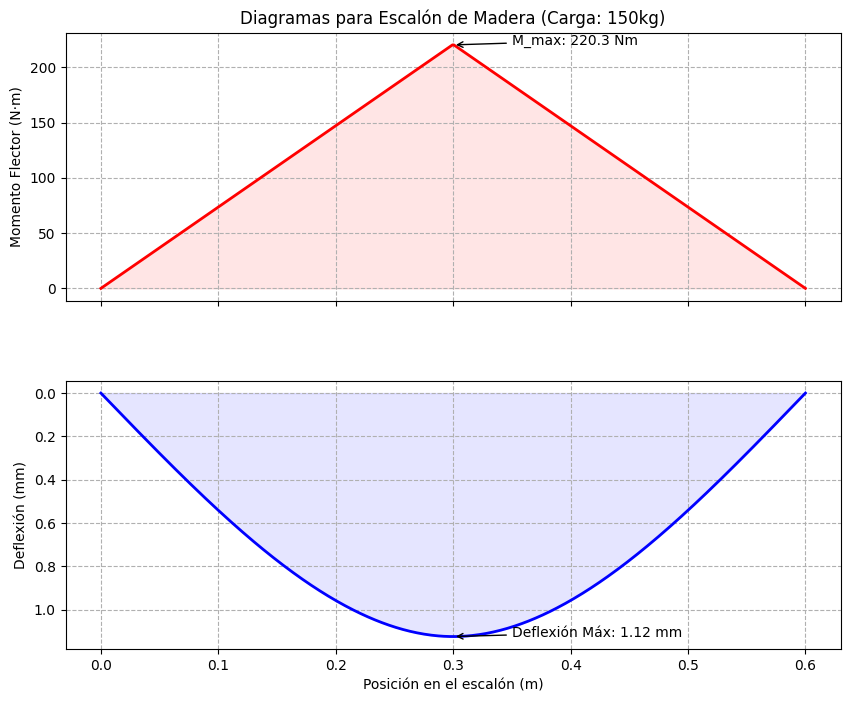

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calcular_viga_escalon():
    # --- 1. Parámetros de diseño (Valores en SI: m, N, Pa) ---
    L = 0.6          # Largo del escalón (distancia entre apoyos)
    ancho_b = 0.15   # Profundidad del escalón (0.15 m = 15 cm)
    alto_h = 0.035   # Espesor del escalón (0.035 m = 3.5 cm)
    
    E = 11e9         # Módulo de Young de la madera (Pino aprox. 11 GPa)
    masa = 150       # Masa en kg
    P = masa * 9.81  # Carga puntual en Newton
    a = L / 2        # Posición de la carga (en el centro del escalón)
    
    # --- 2. Cálculos Geométricos y Estáticos ---
    # Momento de Inercia para sección rectangular (I = b*h^3 / 12)
    I = (ancho_b * (alto_h**3)) / 12
    
    # Reacciones en los apoyos (Simetría)
    R1 = P / 2
    R2 = P / 2
    
    # --- 3. Generación de Diagramas ---
    x = np.linspace(0, L, 500)
    momento = np.zeros_like(x)
    deflexion = np.zeros_like(x)
    
    for i, xi in enumerate(x):
        # Momento Flector M(x)
        if xi <= a:
            momento[i] = R1 * xi
        else:
            momento[i] = R1 * xi - P * (xi - a)
            
        # Deflexión y(x) - Ecuación de la elástica para carga puntual
        # b_dist es la distancia desde la carga al apoyo derecho
        b_dist = L - a
        if xi <= a:
            # Fórmula para x <= a
            deflexion[i] = (P * b_dist * xi) / (6 * E * I * L) * (L**2 - b_dist**2 - xi**2)
        else:
            # Fórmula para x > a (por simetría o despeje)
            deflexion[i] = (P * a * (L - xi)) / (6 * E * I * L) * (L**2 - a**2 - (L - xi)**2)

    # Convertir deflexión a milímetros para mejor visualización
    deflexion_mm = deflexion * 1000
    max_def = np.max(deflexion_mm)

    # --- 4. Visualización ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    plt.subplots_adjust(hspace=0.3)

    # Gráfico de Momento Flector
    ax1.plot(x, momento, color='red', linewidth=2)
    ax1.fill_between(x, momento, color='red', alpha=0.1)
    ax1.set_ylabel('Momento Flector (N·m)')
    ax1.set_title(f'Diagramas para Escalón de Madera (Carga: {masa}kg)')
    ax1.grid(True, linestyle='--')
    ax1.annotate(f'M_max: {np.max(momento):.1f} Nm', xy=(a, np.max(momento)), 
                 xytext=(a+0.05, np.max(momento)), arrowprops=dict(arrowstyle='->'))

    # Gráfico de Deflexión (se invierte el eje Y para ver la caída)
    ax2.plot(x, deflexion_mm, color='blue', linewidth=2)
    ax2.fill_between(x, deflexion_mm, color='blue', alpha=0.1)
    ax2.set_ylabel('Deflexión (mm)')
    ax2.set_xlabel('Posición en el escalón (m)')
    ax2.invert_yaxis()  # Para que la deformación se vea hacia abajo
    ax2.grid(True, linestyle='--')
    ax2.annotate(f'Deflexión Máx: {max_def:.2f} mm', xy=(a, max_def), 
                 xytext=(a+0.05, max_def), arrowprops=dict(arrowstyle='->'))

    print(f"--- Resultados del Análisis ---")
    print(f"Momento de Inercia (I): {I:.2e} m^4")
    print(f"Momento Máximo: {np.max(momento):.2f} Nm")
    print(f"Deflexión Máxima en el centro: {max_def:.2f} mm")
    
    plt.show()

if __name__ == "__main__":
    calcular_viga_escalon()

     --- ANÁLISIS DE SEGURIDAD ---      
Carga aplicada: 150 kg (1471.5 N)
Esfuerzo calculado (sigma): 4.17 MPa
Tensión Admisible (con FS=5.0): 14.00 MPa
✅ RESISTENCIA: El escalón SOPORTA el peso con buen margen.
----------------------------------------
Deflexión calculada: 0.94 mm
Límite recomendado (L/360): 1.67 mm
✅ RIGIDEZ: El escalón se siente firme.


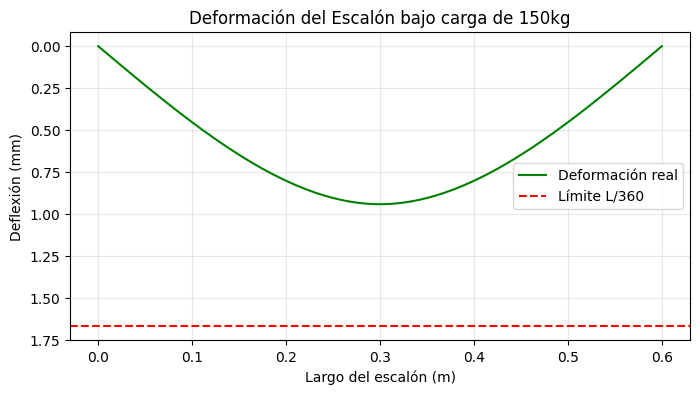

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def analizar_seguridad_escalon():
    # --- 1. CONFIGURACIÓN DEL MATERIAL Y GEOMETRÍA ---
    L = 0.6          # Largo (m)
    b = 0.22       # Ancho de la tabla (m)
    h = 0.038        # Espesor de la tabla (m)
    
    # Propiedades del Pino (Valores promedio)
    E = 7e9         # Pa (11 GPa)
    MOR = 70e6       # Pa (85 MPa - Punto de rotura)
    FS = 5.0         # Factor de Seguridad deseado
    sigma_adm = MOR / FS
    
    masa_persona = 150  # kg
    P = masa_persona * 9.81
    
    # --- 2. CÁLCULOS ESTÁTICOS ---
    I = (b * h**3) / 12  # Momento de inercia
    M_max = (P * L) / 4  # Momento máximo en el centro
    c = h / 2            # Distancia del eje neutro a la fibra extrema
    
    # Esfuerzo máximo de flexión (Fórmula de la escuadría)
    sigma_max = (M_max * c) / I
    
    # Deflexión máxima (Flecha)
    delta_max = (P * L**3) / (48 * E * I)
    
    # Límites de ingeniería
    limite_confort = L / 360
    
    # --- 3. IMPRESIÓN DE RESULTADOS ---
    print(f"{'--- ANÁLISIS DE SEGURIDAD ---':^40}")
    print(f"Carga aplicada: {masa_persona} kg ({P:.1f} N)")
    print(f"Esfuerzo calculado (sigma): {sigma_max/1e6:.2f} MPa")
    print(f"Tensión Admisible (con FS={FS}): {sigma_adm/1e6:.2f} MPa")
    
    if sigma_max < sigma_adm:
        print("✅ RESISTENCIA: El escalón SOPORTA el peso con buen margen.")
    elif sigma_max < MOR:
        print("⚠️ PRECAUCIÓN: El escalón aguanta pero el factor de seguridad es bajo.")
    else:
        print("❌ PELIGRO: El escalón se ROMPERÁ.")
        
    print("-" * 40)
    print(f"Deflexión calculada: {delta_max*1000:.2f} mm")
    print(f"Límite recomendado (L/360): {limite_confort*1000:.2f} mm")
    
    if delta_max < limite_confort:
        print("✅ RIGIDEZ: El escalón se siente firme.")
    else:
        print("💡 NOTA: El escalón es seguro pero podría sentirse 'elástico'.")

    # --- 4. GRÁFICO ---
    x = np.linspace(0, L, 500)
    # Ecuación de la elástica simplificada
    y = (P * x / (48 * E * I)) * (3 * L**2 - 4 * x**2) if any(x <= L/2) else 0 # Simplificado para visualización
    # Para el gráfico usamos la función completa tramo a tramo
    y_plot = np.where(x <= L/2, 
                      (P * x * (3*L**2 - 4*x**2)) / (48 * E * I),
                      (P * (L - x) * (3*L**2 - 4*(L - x)**2)) / (48 * E * I))

    plt.figure(figsize=(8, 4))
    plt.plot(x, y_plot * 1000, label='Deformación real', color='green')
    plt.axhline(y=limite_confort*1000, color='red', linestyle='--', label='Límite L/360')
    plt.gca().invert_yaxis()
    plt.title("Deformación del Escalón bajo carga de 150kg")
    plt.ylabel("Deflexión (mm)")
    plt.xlabel("Largo del escalón (m)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    analizar_seguridad_escalon()

--- Resultados de la Viga ---
Reacción A (Izquierda): 2.00 kN
Reacción B (Derecha): 6.00 kN
Momento Máximo (en la carga): 17.99 kNm
Deflexión Máxima: 16.77 mm
Posición de la deflexión máx: 6.70 m


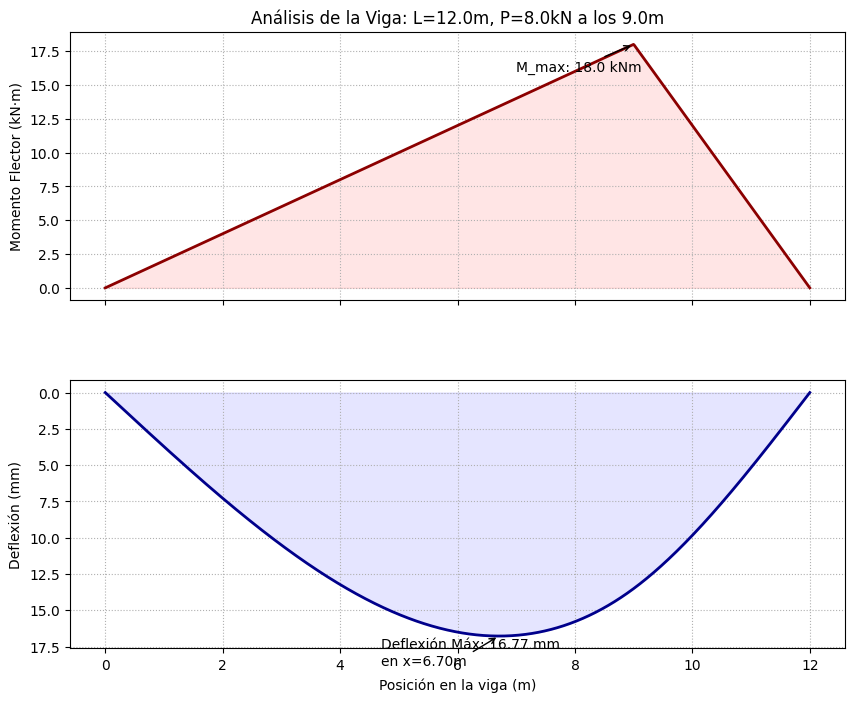

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def calcular_viga_imagen():
    # --- 1. Parámetros de la viga (Unidades SI: m, N, Pa) ---
    L = 12.0          # Longitud total (9m + 3m)
    a = 9.0           # Distancia del apoyo izquierdo a la carga
    b_dist = L - a    # Distancia de la carga al apoyo derecho (3m)
    P = 8000.0        # Carga puntual (8 kN)
    
    E = 200e9         # Módulo de Young (200 GPa para acero)
    # Conversión de mm4 a m4: 60e6 * (1e-3)^4 = 60e6 * 1e-12 = 6e-5
    I = 60e6 * 1e-12  
    
    # --- 2. Reacciones y Momentos ---
    # Por estática: RA*L = P*b_dist => RA = P*b_dist/L
    RA = (P * b_dist) / L  # Debería dar 2000 N (2 kN)
    RB = (P * a) / L       # Debería dar 6000 N (6 kN)
    
    # --- 3. Cálculo de Diagramas ---
    x = np.linspace(0, L, 1000)
    momento = np.zeros_like(x)
    deflexion = np.zeros_like(x)
    
    for i, xi in enumerate(x):
        # Momento flector M(x)
        if xi <= a:
            momento[i] = RA * xi
        else:
            momento[i] = RA * xi - P * (xi - a)
            
        # Deflexión y(x) usando la ecuación de la elástica
        if xi <= a:
            # Fórmula para el tramo largo (x <= a)
            deflexion[i] = (P * b_dist * xi) / (6 * E * I * L) * (L**2 - b_dist**2 - xi**2)
        else:
            # Fórmula para el tramo corto (x > a)
            # Usamos la simetría respecto al otro apoyo para facilitar el cálculo
            x_rev = L - xi
            deflexion[i] = (P * a * x_rev) / (6 * E * I * L) * (L**2 - a**2 - x_rev**2)

    # Conversión de resultados
    momento_knm = momento / 1000
    deflexion_mm = deflexion * 1000
    max_def = np.max(deflexion_mm)
    x_max_def = x[np.argmax(deflexion_mm)]

    # --- 4. Visualización ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    plt.subplots_adjust(hspace=0.3)

    # Gráfico de Momento Flector
    ax1.plot(x, momento_knm, color='darkred', linewidth=2)
    ax1.fill_between(x, momento_knm, color='red', alpha=0.1)
    ax1.set_ylabel('Momento Flector (kN·m)')
    ax1.set_title(f'Análisis de la Viga: L={L}m, P={P/1000}kN a los {a}m')
    ax1.grid(True, linestyle=':')
    ax1.annotate(f'M_max: {np.max(momento_knm):.1f} kNm', xy=(a, np.max(momento_knm)), 
                 xytext=(a-2, np.max(momento_knm)-2), arrowprops=dict(arrowstyle='->'))

    # Gráfico de Deflexión
    ax2.plot(x, deflexion_mm, color='darkblue', linewidth=2)
    ax2.fill_between(x, deflexion_mm, color='blue', alpha=0.1)
    ax2.set_ylabel('Deflexión (mm)')
    ax2.set_xlabel('Posición en la viga (m)')
    ax2.invert_yaxis()  # La deformación es hacia abajo
    ax2.grid(True, linestyle=':')
    ax2.annotate(f'Deflexión Máx: {max_def:.2f} mm\nen x={x_max_def:.2f}m', xy=(x_max_def, max_def), 
                 xytext=(x_max_def-2, max_def+2), arrowprops=dict(arrowstyle='->'))

    print(f"--- Resultados de la Viga ---")
    print(f"Reacción A (Izquierda): {RA/1000:.2f} kN")
    print(f"Reacción B (Derecha): {RB/1000:.2f} kN")
    print(f"Momento Máximo (en la carga): {np.max(momento_knm):.2f} kNm")
    print(f"Deflexión Máxima: {max_def:.2f} mm")
    print(f"Posición de la deflexión máx: {x_max_def:.2f} m")
    
    plt.show()

if __name__ == "__main__":
    calcular_viga_imagen()